## Lake Zug Retreat Day 1

In [1]:
# imports
import ewgreaders as ewg
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

In [2]:
lake = 'Zug'

di_ctd = ewg.get_data_index(lake, 'ctd')
di_m = ewg.get_data_index(lake, 'mooring')

bathy = xr.open_dataset('Q:/Messdaten/Aphys_Hypothesis_data/Zug/bathymetry.nc')

### Processes schematic

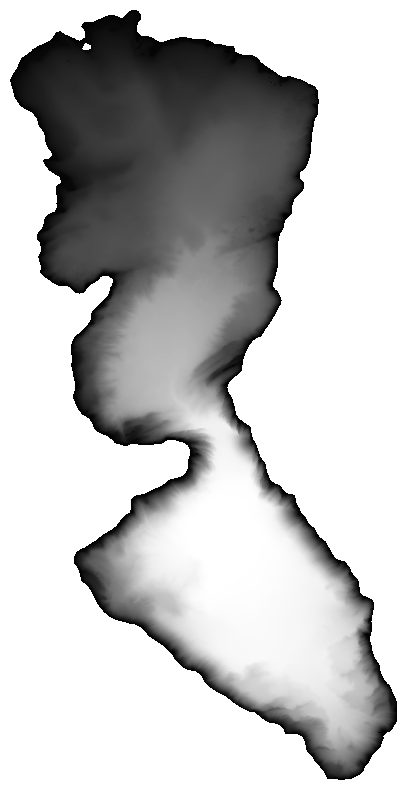

In [7]:
fig, ax = plt.subplots(figsize=(5, 10))

im = ax.pcolormesh(bathy['xsc'], bathy['ysc'], bathy['depth'], cmap='Greys_r', vmin=0, rasterized=True)

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/zug_retreat/zug_map.svg', bbox_inches='tight')
plt.show()

### Oxygen overturn within anoxic zone

In [4]:
date = '2026-03-20'
di_sel = di_ctd.query("date == @date")

C:\Users\herremha\AppData\Local\Temp\ipykernel_16940\4007649183.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_sel = di_ctd.query("date == @date")


In [5]:
p = di_sel.iloc[4]
ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
ds = ctdreader.load()
ds['do2_conc'] = ds['do2_conc'] - ds['do2_conc'].min()    # anoxic
ds['do2_conc'] = ds['do2_conc'] * (1000/32)               # convert to umol/L

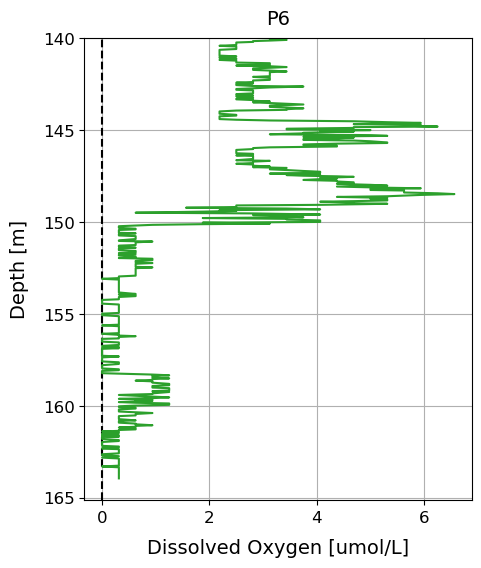

In [8]:
z_min = 140
ds_sel = ds.sel(depth=slice(z_min, None))

fig, ax = plt.subplots(figsize=(5, 6))

ax.axvline(0, color='black', linestyle='--')
sns.lineplot(x=ds_sel.do2_conc, y=ds_sel.depth, orient='y', color='tab:green', ax=ax)

ax.set_xlabel('Dissolved Oxygen [umol/L]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title(p.profile_loc, fontsize=14, pad=10)
ax.tick_params(axis='both', labelsize=12)

ax.set_ylim(z_min, None)
ax.invert_yaxis()
ax.grid(True)

plt.show()

### Boundary Mixing at Thermocline

Turbidity current

In [23]:
date = '2025-02-14'
di_ctd_sel = di_ctd.query("date == @date and serial_id == 1807")

C:\Users\herremha\AppData\Local\Temp\ipykernel_16940\2008337234.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_ctd_sel = di_ctd.query("date == @date and serial_id == 1807")


  0%|          | 0/12 [00:00<?, ?it/s]

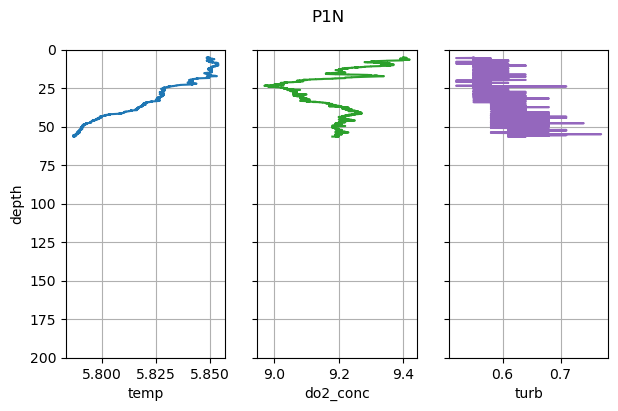

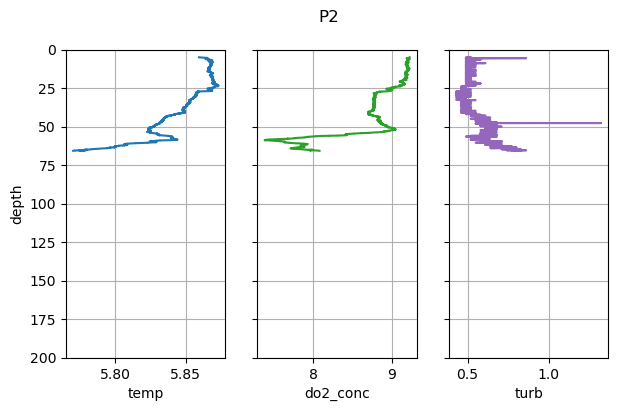

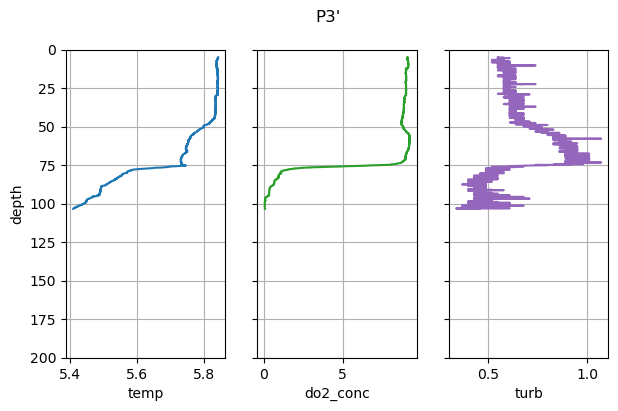

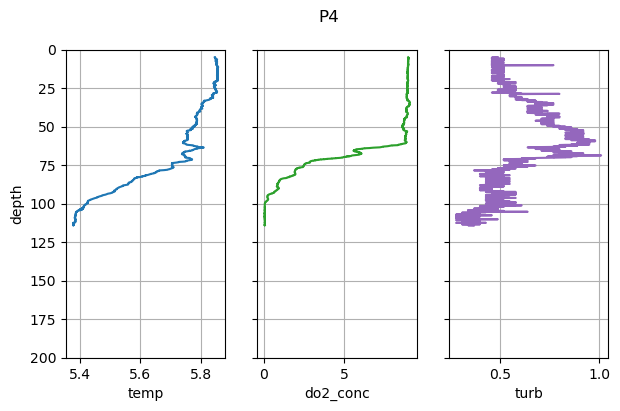

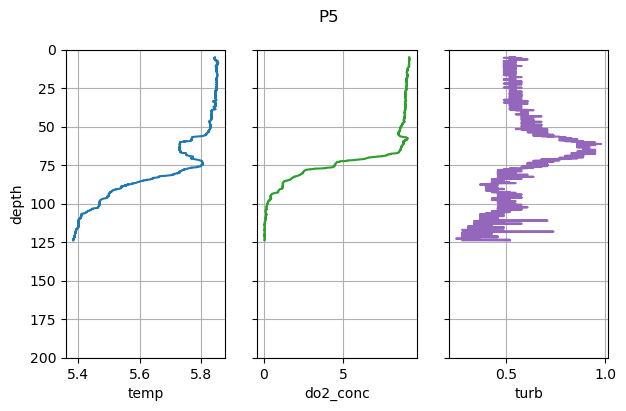

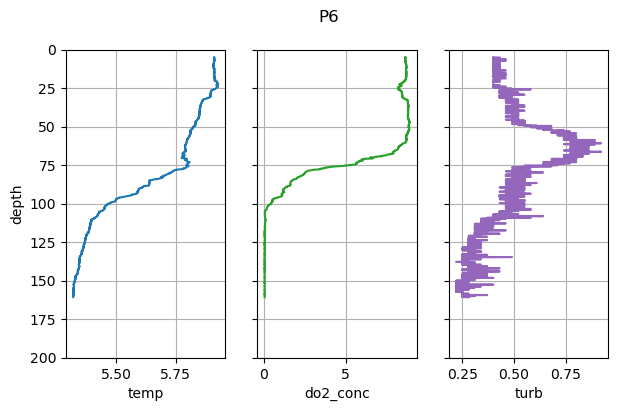

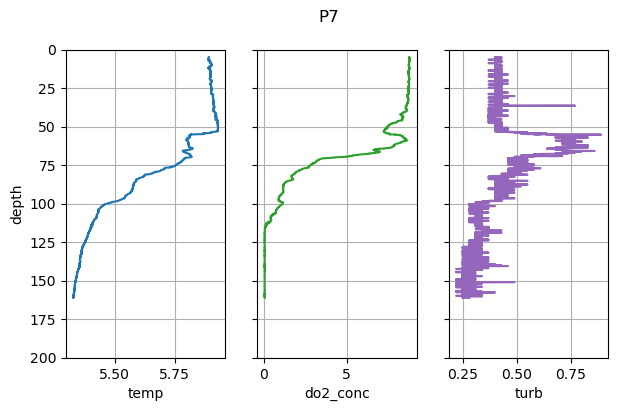

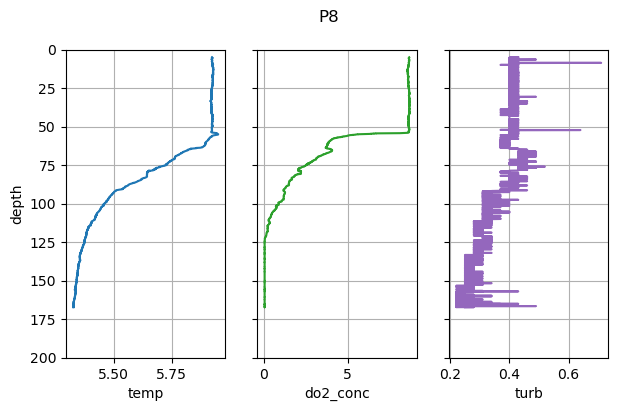

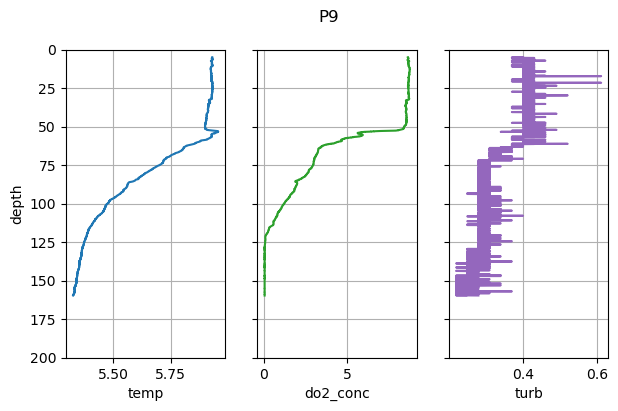

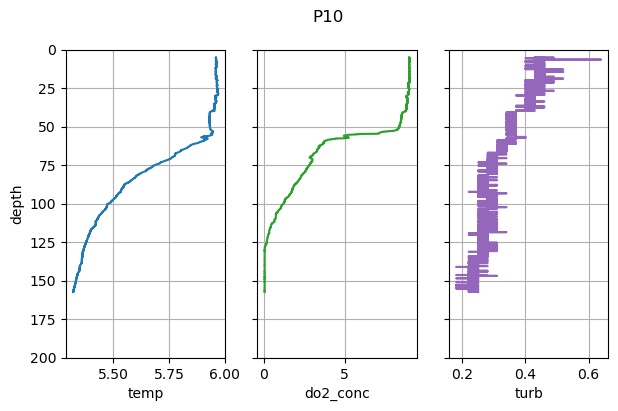

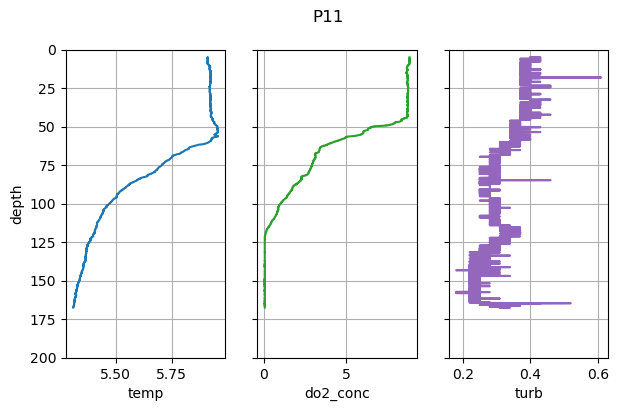

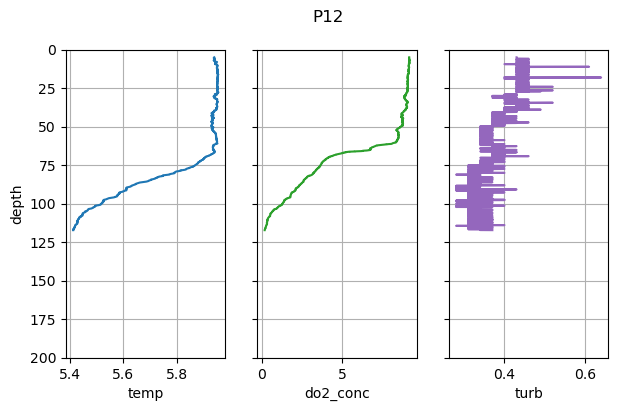

In [31]:
for _, p in tqdm(di_ctd_sel.iterrows(), total=len(di_ctd_sel)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()
    ds = ds.sel(depth=slice(5, None))

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(7, 4), sharey=True)
    sns.lineplot(x=ds.temp, y=ds.depth, color='tab:blue', orient='y', ax=ax[0])
    sns.lineplot(x=ds.do2_conc, y=ds.depth, color='tab:green', orient='y', ax=ax[1])
    sns.lineplot(x=ds.turb, y=ds.depth, color='tab:purple', orient='y', ax=ax[2])
    fig.suptitle(p.profile_loc)
    ax[0].set_ylim(0, 200)
    ax[0].invert_yaxis()
    ax[0].grid(True)
    ax[1].grid(True)
    ax[2].grid(True)
    plt.show()

### CTD Overturns

In [9]:
for _, row in tqdm(di_ctd.iterrows(), total=len(di_ctd)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()

  0%|          | 0/288 [00:00<?, ?it/s]

In [11]:
do = ds['do2_conc']
depth = ds['depth']

In [12]:
data = []
idx = 0
for i in range(1, len(do)):
    # don't double count
    if i < idx:
        continue

    # start of inversion
    if do[i] > do[i-1]:
        do_max = do[i]
        for j in range(i, len(do)):
            if do_max[j] > do_max:
                do_max = do[j]

            # end of inversion
            if do[j] < do[i-1] and depth[j] > depth[j-1]:
                data.append({
                    'depth_start': depth[i-1],
                    'depth_end': depth[j],
                    'depth_range': depth[j] - depth[i-1],
                    'do_min': do[i-1],
                    'do_max': do_max,
                    'do_diff': do_max - do[i-1]
                })
                idx = j
                break

IndexError: too many indices

### Hydraulic control

Internal Froude number

In [ ]:
def reduced_gravity(rho1, rho2):
    g = 9.81
    
    return g * (rho2 - rho1) / max([rho1, rho2])

def internal_froude_number(U, h, g_prime):
    return U / np.sqrt(g_prime * h)


def composite_froude_number(Fr1, Fr2):
    return Fr1**2 + Fr2**2

In [ ]:
g = 8.91
